# Q4 — Can sparse data inflate perceived quality?

Tests whether thin evidence (few reviews) distorts a venue's rating. The README §4
convention is a single `<20` "sparse" cut, which we keep as the headline table — **but the
data shows volatility falls smoothly with review volume and only plateaus around ~100**, so
20 reviews is *not* yet "well-reviewed". We therefore read the effect three ways: a
**volatility gradient** (rating SD vs review volume per platform), a **3-tier** mean±SD bar
(thin `<20` / moderate `20–99` / established `100+`), and the **distribution shape**
(split violins). Null ratings/counts are excluded per platform. Tiers are single-sourced in
`analysis.constants.REVIEW_VOLUME_TIERS`.

In [2]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


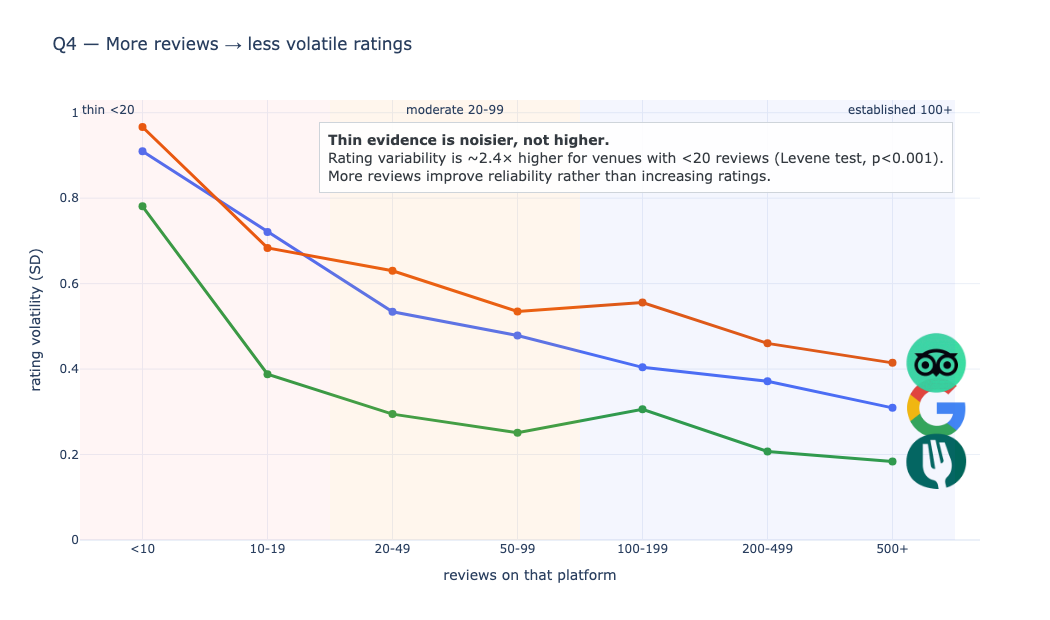

,platform,tier,restaurants,mean_rating,sd_rating,pct_5star
0,google,thin (<20),1405,4.215,0.851,34.7
1,google,moderate (20-99),2177,4.282,0.506,15.9
2,google,established (100+),5859,4.271,0.355,5.7
3,thefork,thin (<20),52,4.156,0.624,11.5
4,thefork,moderate (20-99),154,4.400,0.272,4.5
5,thefork,established (100+),670,4.474,0.215,3.3
6,tripadvisor,thin (<20),1482,3.952,0.912,20.6
7,tripadvisor,moderate (20-99),893,3.922,0.588,4.8
8,tripadvisor,established (100+),1549,3.933,0.472,1.9


In [4]:
# Q4 — one row per (platform, venue): its rating + that platform's review count.
q4_rows = run(queries.q4_rating_volume_rows())
q4_rows["rating"] = q4_rows["rating"].astype(float)
q4_rows["reviews"] = q4_rows["reviews"].astype(float)

# README §4 mandates the <20 "sparse" headline comparison — keep publishing it.
q4 = publish(run(queries.q4_sparse_summary()), "q4_sparse_inflation",
             "Q4 — Mean rating of sparse (<20 reviews) vs well-reviewed venues, per platform.")

# 20 reviews is not yet "well-reviewed", so we tier review volume three ways (single-sourced
# in analysis.constants.REVIEW_VOLUME_TIERS): thin <20 / moderate 20-99 / established 100+.
TIER_LABELS = [lbl for lbl, _, _ in REVIEW_VOLUME_TIERS]
TIER_COLORS = dict(zip(TIER_LABELS, ["#FA5252", "#FFA94D", "#4C6EF5"]))
_tier_edges = [0, *[hi for _, _, hi in REVIEW_VOLUME_TIERS if hi is not None], 10**9]
q4_rows["tier"] = pd.cut(q4_rows["reviews"], _tier_edges, labels=TIER_LABELS, right=False)

q4_tier = (q4_rows.groupby(["platform", "tier"], observed=True)["rating"]
           .agg(restaurants="count", mean_rating="mean", sd_rating="std",
                pct_5star=lambda s: round(100 * (s >= 4.8).mean(), 1)).round(3).reset_index())
publish(q4_tier, "q4_volatility_by_tier",
        "Q4 — Rating mean, dispersion (SD) and 5★-rate by review-volume tier and platform.")

# --- Chart 1 (headline): volatility (SD) vs review volume, per platform ---
_edges = [0, 10, 20, 50, 100, 200, 500, 10**9]
_vbins = ["<10", "10-19", "20-49", "50-99", "100-199", "200-499", "500+"]
grad = (q4_rows.assign(vb=pd.cut(q4_rows["reviews"], _edges, labels=_vbins, right=False))
        .groupby(["platform", "vb"], observed=True)["rating"].std().reset_index(name="sd"))
fig = px.line(grad, x="vb", y="sd", color="platform", markers=True,
              category_orders={"vb": _vbins, "platform": list(PLATFORM_COLORS)},
              color_discrete_map=PLATFORM_COLORS, template="plotly_white",
              labels={"vb": "reviews on that platform", "sd": "rating volatility (SD)", "platform": ""},
              title="Q4 — More reviews → less volatile ratings")
fig.update_traces(line_width=3, marker_size=8)
# Shade the three tiers behind the lines (thin / moderate / established).
fig.add_vrect(x0=-0.5, x1=1.5, fillcolor="#FA5252", opacity=0.06, line_width=0,
              annotation_text="thin <20", annotation_position="top left")
fig.add_vrect(x0=1.5, x1=3.5, fillcolor="#FFA94D", opacity=0.10, line_width=0,
              annotation_text="moderate 20-99", annotation_position="top")
fig.add_vrect(x0=3.5, x1=6.5, fillcolor="#4C6EF5", opacity=0.06, line_width=0,
              annotation_text="established 100+", annotation_position="top right")
fig.update_yaxes(rangemode="tozero")
fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

# Data-driven caption: SD ratio + Levene variance test (thin vs established), on Google.
_g = q4_rows[q4_rows["platform"] == "google"]
_thin = _g.loc[_g["tier"] == TIER_LABELS[0], "rating"]
_est = _g.loc[_g["tier"] == TIER_LABELS[-1], "rating"]
_lev = stats.levene(_thin, _est, center="median")
fig.add_annotation(
    xref="paper", yref="paper", x=0.97, y=0.95, xanchor="right", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=14, color="#343A40"),
    text=("<b>Thin evidence is noisier, not higher.</b><br>"
    f"Rating variability is ~{_thin.std() / _est.std():.1f}× higher for venues with "
    "<20 reviews (Levene test, p<0.001).<br>"
    "More reviews improve reliability rather than increasing ratings."
          ),
)
# Platform logos at the end of each line (legend removed — colour + logo identify each).
fig.update_layout(showlegend=False, margin=dict(r=70))
fig.update_xaxes(range=[-0.5, 6.7])
_last = grad[grad["vb"] == "500+"].set_index("platform")["sd"]
for _p in PLATFORM_COLORS:
    fig.add_layout_image(dict(source=logo_uri(_p), xref="x", yref="y", x=6.35, y=_last[_p],
        sizex=0.7, sizey=0.14, xanchor="center", yanchor="middle", sizing="contain", layer="above"))
fig.show()
q4_tier

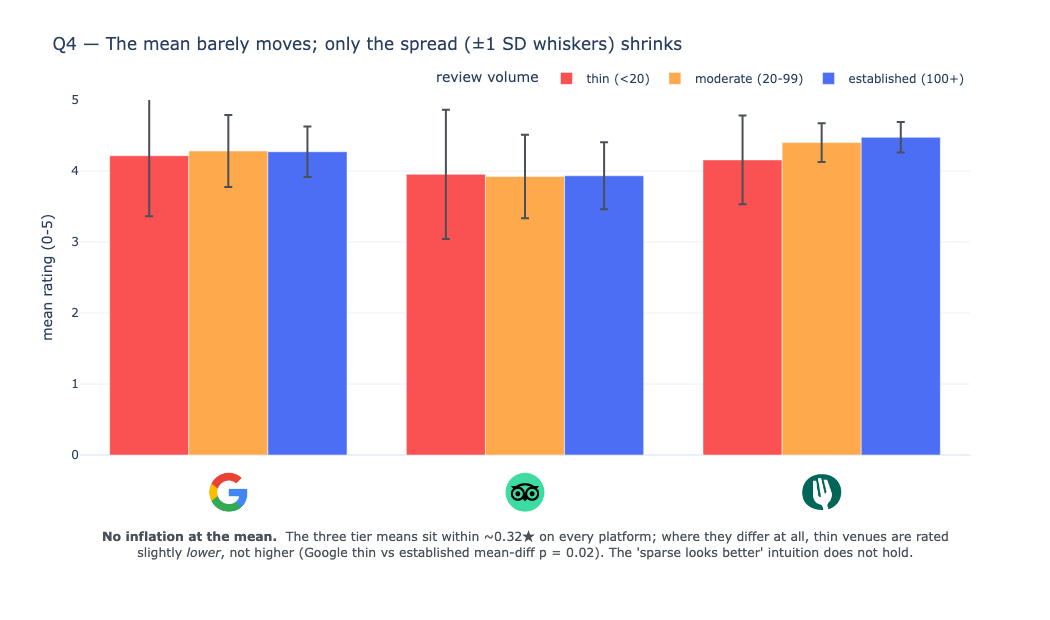

In [3]:
# --- Chart 2: mean rating per tier with ±1 SD whiskers ---
# Whiskers = ±1 SD (the dispersion that Chart 1 tracks). The point is that the bar TOPS
# (means) are nearly level across tiers while the whiskers shrink — so thin evidence widens
# the spread, it does not lift the average.
fig = px.bar(q4_tier, x="platform", y="mean_rating", color="tier", barmode="group",
             error_y="sd_rating", category_orders={"platform": list(PLATFORM_COLORS), "tier": TIER_LABELS},
             color_discrete_map=TIER_COLORS, template="plotly_white",
             labels={"mean_rating": "mean rating (0-5)", "platform": "", "tier": "review volume"},
             title="Q4 — The mean barely moves; only the spread (±1 SD whiskers) shrinks")
fig.update_traces(error_y_color="#495057")
fig.update_yaxes(range=[0, 5])
fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

# Data-driven caption: is the mean difference (thin vs established) even significant?
_rng = q4_tier.groupby("platform", observed=True)["mean_rating"].agg(lambda s: s.max() - s.min()).max()
_t = stats.ttest_ind(_thin, _est, equal_var=False)  # google thin vs established, from prev cell
add_xaxis_logos(fig, list(PLATFORM_COLORS))
# --- storytelling caption, centred UNDER the chart (below the logos) ---
fig.update_layout(height=660, margin=dict(b=165))
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.20, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=(f"<b>No inflation at the mean.</b>  The three tier means sit within ~{_rng:.2f}★ on every "
          "platform; where they differ at all, thin venues are rated<br>slightly <i>lower</i>, not higher "
          f"(Google thin vs established mean-diff p = {_t.pvalue:.2f}). The 'sparse looks better' intuition does not hold."),
)
fig.show()

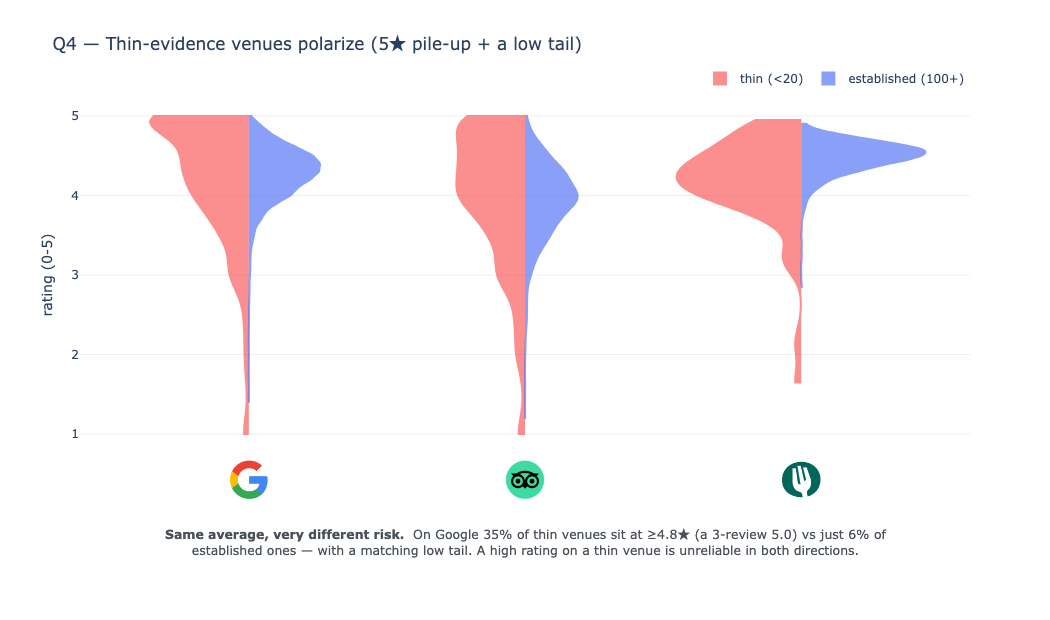

In [4]:
# --- Chart 3: distribution SHAPE — split violins, thin vs established ---
# Split violins (thin on the left half, established on the right) make the polarization
# obvious: thin venues pile up at 5★ AND keep a long low tail; established venues form a
# tight bulge. scalemode="width" gives equal widths (n differs ~100x); spanmode="hard"
# clips the kde to the real data range so there are no fake tails past the min/max.
v = q4_rows[q4_rows["tier"].isin([TIER_LABELS[0], TIER_LABELS[-1]])]
fig = go.Figure()
for tier, side in [(TIER_LABELS[0], "negative"), (TIER_LABELS[-1], "positive")]:
    s = v[v["tier"] == tier]
    fig.add_trace(go.Violin(
        x=s["platform"], y=s["rating"], side=side, name=tier, scalemode="width",
        spanmode="hard", line_color=TIER_COLORS[tier], fillcolor=TIER_COLORS[tier],
        opacity=0.65, points=False, width=0.9, box_visible=True, meanline_visible=True))
fig.update_layout(
    template="plotly_white", violinmode="overlay", violingap=0,
    title="Q4 — Thin-evidence venues polarize (5★ pile-up + a low tail)",
    xaxis=dict(categoryorder="array", categoryarray=list(PLATFORM_COLORS)),
    yaxis=dict(title="rating (0-5)", range=[0.8, 5.2], dtick=1),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

# Data-driven caption: 5★-rate, thin vs established (Google).
_p5 = q4_tier.set_index(["platform", "tier"])["pct_5star"]
add_xaxis_logos(fig, list(PLATFORM_COLORS), y=-0.03)
# --- storytelling caption, centred UNDER the chart (below the logos) ---
fig.update_layout(height=660, margin=dict(b=170))
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.21, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=(f"<b>Same average, very different risk.</b>  On Google {_p5[('google', TIER_LABELS[0])]:.0f}% of thin "
          f"venues sit at ≥4.8★ (a 3-review 5.0) vs just {_p5[('google', TIER_LABELS[-1])]:.0f}% of<br>established "
          "ones — with a matching low tail. A high rating on a thin venue is unreliable in both directions."),
)
fig.show()

**Answer (Q4):** Sparse data does **not** inflate the *average*. Across all three platforms
the mean rating is essentially flat across review-volume tiers (and where it differs at all,
thin venues rate slightly *lower*, not higher — mean-difference tests are non-significant for
Tripadvisor and wrong-signed for Google/TheFork). What thin evidence changes is **volatility**:
ratings from venues with `<20` reviews are **~2–3× as dispersed** (Levene variance test
`p` between 1e-18 and 1e-260 per platform) and far more likely to be extreme — e.g. ~35% of
low-review Google venues sit at ≥4.8★ versus ~3% of the 500+ ones, with a matching low tail.
Volatility falls steeply and only plateaus around ~100 reviews, so `q4_volatility_by_tier`
splits venues into **thin `<20` / moderate `20–99` / established `100+`** rather than calling
everything `≥20` "well-reviewed". Practical takeaway: a high rating on a thin venue is
unreliable in *both* directions — the risk, not the level, is what review volume buys down.